## 570 Adverserial Search

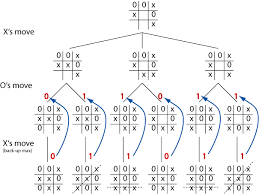

Adverserial search was covered in class but not much depth.

How it works is that you create a tree graph going through all possible input combinations of both players.

Then, once the graph is completed, you assign the leaf nodes a score. Such as +1 for x winning, -1 for o winning, and 0 for stalemate.

You work recursively upwards, so for every non-leaf node, the value of that node will either be the maximum of all it's branches if it's x's turn or the minimum of all it's branches if it's o's turn.

In the above example, if you look at the first branch from the root node, this branch will have a value of 0. That's because the values of the sub branches are 0 and 1, and since it's o's turn to move, it is trying to minimize it's score, so player o will go for the sub branch with a value of 0, thus the entire branch has a value of 0.

However, if you look at the last branch of the root node, this will have a value of 1, since all the sub branches have a value of 1. No matter what o does, x is guaranteed a win. Thus, the optimal move for x given the board shown in the root is to place his x on the bottom left square, as, if he plays the rest of the game perfectly, can guarantee an outcome of at least +1.

There is also a concpet called Alpha-Beta prunning, which allows you to get the same results with less computational power.

For example, let's say X root node has two branches. You calculate the value of the first branch and it has a score of +1. Then you go onto the second branch, in which it's o's turn to move and minimize the overall score. The first sub-branch in this second branch has a score of 0. You can stop calculating here, because player o will never pick a branch that has a score of +1 when it has a better option of 0. So the highest possible value of this second branch will be 0, which is lower than the value of the first branch, so calculating the rest is not necessary.

One problem is that containing all the graphs for all possible combinations can get pretty computationally expensive after just a few moves. So one method to deal with this is to have a heuristic to estimate if one player is doing better than the other without actually going all the way to a win state.

I have downloaded a chess program (https://levelup.gitconnected.com/chess-python-ca4532c7f5a4) and modified it with an AI that uses adverseral search in order to move. This got very expensive very quickly so the AI can only look one full turn ahead of time. The heuristic is the material advantage one player has over the other, with of course checkmate counting as + or - 200 depending on who has checkmate.



In [ ]:
def computerTurn(board, turnNum):
    moves = {}
    ##THIS CHUNK GOES THROUGH BOARD TO FIND ALL COMBINATIONS OF MOVES
    ## WITH CURRENT PIECES AND PLACES THEM IN DICTIONARY
    for i in range(8):
        for j in range(8):
            copyBoard = copy.deepcopy(board)
            if copyBoard[i][j] != 'x 'and copyBoard[i][j] != '  ':
                if copyBoard[i][j].team == compPlayer:
                    select_moves_temp(copyBoard[i][j], (i, j), copyBoard)
                    for c in range(8):
                        for d in range(8):
                            if copyBoard[c][d] == 'x ':
                                moves[((i, j), (c, d))] = 0
                            if copyBoard[c][d] != '  ' and copyBoard[c][d] != 'x ':
                                if copyBoard[c][d].killable == True:
                                    moves[((i, j), (c, d))] = 0
                    copyBoard = resetPotential(copyBoard)

    ##THIS CODE WILL EXECTUE THE MOVE IN A COPY OF THE ORIGIAL BOARD
    ##THE FIND THE SCORE OF THAT MOVE
    for move in moves:
        copyBoard[move[1][0]][move[1][1]] = copyBoard[move[0][0]][move[0][1]]
        copyBoard[move[0][0]][move[0][1]] = '  '
        if turnNum % 2 == 0:
            if availableMoves(copyBoard, 'w') is False:
                if isItCheck(copyBoard, 'b'):
                    moves[move] = -200 ## BLACK VICTORY
                moves[move] = 0 ## STALEMATE
        else:
            if availableMoves(copyBoard, 'b') is False:
                if isItCheck(copyBoard, 'w'):
                    moves[move] = 200 ## WHITE VICTORY
                moves[move] = 0
        moves[move] = calculateMove(copyBoard, turnNum + 1, 0) ## RECURSIVELY FIND HEURSTIC VALUE
        copyBoard = copy.deepcopy(board)

    if compPlayer == 'w': ## IF COMPUTER PLAYER IS WHITE, MAXIMIZE SCORE
        return max(moves, key=moves.get)
    else: ## IF BLACK THEN MINIMIZE SCORE
        return min(moves, key=moves.get)

In [ ]:
def totalPoints(board): ## HEURISTIC IN CASE MOVE DOESNT END
    total = 0
    for i in range(8):
        for j in range(8):
            if board[i][j] != 'x 'and board[i][j] != '  ':
                multipler = 1
                if board[i][j].team == 'b':
                    multipler = -1
                if board[i][j].type =='p':
                    total = total + (multipler * 1)
                elif board[i][j].type =='kn':
                    total = total + (multipler * 3)
                elif board[i][j].type =='b':
                    total = total + (multipler * 3)
                elif board[i][j].type =='r':
                    total = total + (multipler * 5)
                elif board[i][j].type =='q':
                    total = total + (multipler * 9)
    return total
## WILL RETURN SCORE FOR THIS BOARD POSITION

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Downloaded in this project is chess.py

simply navigate to directory


/path/to/directory/:python chess.py /(arg/)

where arg is w for white or b for black

## Headers

Make a 3rd level header with your name:

<!--- Write your answer here. --->

## Emphasis

Write 4 of your favorite words using each type of emphasis:

<!--- Write your answer here. --->

## Lists

Make an ordered list of 3 things you hope to achieve this semester, and elaborate on them with sub items. Then, make an unordered list of 3 classes that you're taking this semester:

<!--- Write your answer here. --->

## Links

Write a sentence describing your major, and insert a link to your major's department website:

<!--- Write your answer here. --->

## Images

Insert the image with the URL https://raw.githubusercontent.com/AguaClara/aguaclara_tutorial/master/images/Cornell_University_seal.png using
  1. the `![display text](URL)` format
  2. the HTML format, with adjusted dimensions and/or text alignment

<!--- Write your answer here. --->

## Code Formatting

Put the name of this file in an in-line code format. Hint: use a single backtick (`).

<!-- Write your answer here. -->

## Tables

Create a table listing your 3 favorite animals, books, and places on campus. Use a different alignment for each column.

<!--- Write your answer here. --->

## Blockquotes

Write your favorite quote. It must be attributed to Albert Einstein.

<!-- Write your answer here. -->

## Horizontal Rules

Add a horizontal rule:

<!-- Write your answer here. -->

## LaTeX Formatting

Copy the equation towards the end of the [Markdown tutorial](https://github.com/AguaClara/aguaclara_tutorial/wiki/Markdown#latex-formatting) and paste it here:

<!-- Write your answer here. -->